In [1]:
print("ok")

ok


In [2]:
import sys
print(sys.executable)
# <!-- this is to check Jupyter kernel and your venv are the same. -->

/Users/nanimahi/automated-research-report-generation/venv/bin/python


In [3]:
import importlib.util
print(importlib.util.find_spec("research_and_analyst"))
# it checks - package is discoverable , "yes we see uv pip list but its not garuntee"

ModuleSpec(name='research_and_analyst', loader=<_frozen_importlib_external.SourceFileLoader object at 0x10a61c950>, origin='/Users/nanimahi/automated-research-report-generation/src/research_and_analyst/__init__.py', submodule_search_locations=['/Users/nanimahi/automated-research-report-generation/src/research_and_analyst'])


In [4]:
from research_and_analyst.utils.model_loader import ModelLoader

In [5]:
model_loader = ModelLoader()

GOOGLE_API_KEY is missing in environment variables


In [6]:
llm=model_loader.load_llm()

In [7]:
llm.invoke("hi").content

'Hello! How can I assist you today?'

In [8]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

In [9]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage,HumanMessage , SystemMessage
from langgraph.checkpoint.memory import MemorySaver

health

Analyst( name="Dr. Neha Patel",
 role="Medical Data Scientist", 
 affiliation="Stanford Medicine", 
 description="Focuses on predictive models for patient outcomes."
  )

In [11]:
class Analyst(BaseModel):
    name: str = Field(description="Name of the analyst.")
    role: str = Field(description="Role of the analyst in the context of the topic.")
    affiliation: str = Field(description="Primary affiliation of the analyst.")
    description: str = Field(description="Description of the analyst focus, concerns, and motives.")
    
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

In [12]:
analyst = Analyst(
    name="Mahi",
    role="genai eng",
    affiliation="AI Research LAB",
    description="I am genai developer as well as mentor"
    )


In [13]:
analyst.affiliation

'AI Research LAB'

In [14]:
analyst.persona

'Name: Mahi\nRole: genai eng\nAffiliation: AI Research LAB\nDescription: I am genai developer as well as mentor\n'

In [15]:
analyst.name

'Mahi'

In [16]:
class Perspectives(BaseModel):
       analysts: List[Analyst] = Field(description="Comprehensive list of analysts with their roles and affiliations.")

In [17]:
class GenerateAnalystsState(TypedDict):
    topic: str #research topic
    max_analysts: int # number of analyst
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions

In [18]:
GenerateAnalystsState(
    topic = "finance",
    max_analysts= 5,
    human_analyst_feedback= "give the real info",  
)

{'topic': 'finance',
 'max_analysts': 5,
 'human_analyst_feedback': 'give the real info'}

In [19]:
Analyst(
        name="Dr. Neha Patel",
        role="Medical Data Scientist",
        affiliation="Stanford Medicine",
        description="Focuses on predictive models for patient outcomes."
    )

Analyst(name='Dr. Neha Patel', role='Medical Data Scientist', affiliation='Stanford Medicine', description='Focuses on predictive models for patient outcomes.')

In [20]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [21]:
print([analyst_instructions.format(
        topic="education",
        max_analysts=4,
        human_analyst_feedback="please explain only on AI"
        
        )] + ["Generate the set of analysts."])

['You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:\n\n1. First, review the research topic:\neducation\n\n2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: \n\nplease explain only on AI\n\n3. Determine the most interesting themes based upon documents and / or feedback above.\n\n4. Pick the top 4 themes.\n\n5. Assign one analyst to each theme.', 'Generate the set of analysts.']


In [22]:
def create_analyst(state:GenerateAnalystsState):
    """
    it is creating my analyst
    
    """
    topic = state["topic"]
    max_analysts = state["max_analysts"]
    human_analyst_feedback = state.get("human_analyst_feedback","")
    
    structured_llm = llm.with_structured_output(Perspectives)
    
    system_messages = analyst_instructions.format(
        topic=topic,
        max_analysts=max_analysts,
        human_analyst_feedback=human_analyst_feedback
        
        )
    analysts = structured_llm.invoke([SystemMessage(content=system_messages)]+ [HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}

In [23]:
create_analyst(
    {'topic': 'health',
    'max_analysts': 2,
    'human_analyst_feedback': 'give the real info'}
    )

{'analysts': [Analyst(name='Dr. Emily Chen', role='Public Health Analyst', affiliation='World Health Organization', description='Dr. Chen focuses on global health trends, particularly the impact of pandemics on public health systems. Her work involves analyzing data to improve health outcomes and preparedness for future health crises. She is concerned with equitable access to healthcare and the role of international cooperation in managing health emergencies.'),
  Analyst(name='Dr. Raj Patel', role='Healthcare Technology Analyst', affiliation='MIT Media Lab', description='Dr. Patel specializes in the intersection of technology and healthcare, exploring how innovations like AI and telemedicine can transform patient care. He is interested in the ethical implications of technology in healthcare, data privacy, and how digital tools can improve healthcare accessibility and efficiency.')]}

In [24]:
def human_feedback(state):
    """ No-op node that should be interrupted on """
    pass

In [25]:
def should_continue(state):
    feedback = (state.get("human_analyst_feedback") or "").strip().lower()
    if feedback and feedback not in ["", "none", "skip", "done", "continue"]:
        return "create_analyst"
    return END

In [26]:
# def should_continue(state):
#     """ Return the next node to execute """
#     human_analyst_feedback = state.get("human_analyst_feedback",None)
#     if human_analyst_feedback:
#         return "create_analyst"

In [27]:
from IPython.display import Image, display

First Workflow

In [28]:
builder = StateGraph(GenerateAnalystsState)

In [29]:
builder.add_node("create_analyst",create_analyst)
builder.add_node("human_feedback", human_feedback)

In [30]:
builder.add_edge(START,"create_analyst")
builder.add_edge("create_analyst", "human_feedback")
builder.add_conditional_edges("human_feedback",
                        should_continue,
                        ["create_analyst",
                        END])

In [31]:
memory = MemorySaver()

In [32]:
graph = builder.compile(interrupt_before= ["human_feedback"],checkpointer= memory)

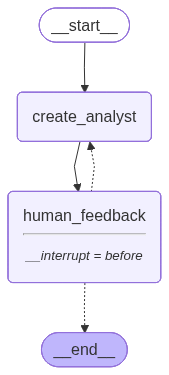

In [33]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [34]:
topic = "the benefits of adopting Langgraph as an agent framework"

In [35]:
max_analysts = 4

In [36]:
thread =  {"configurable":{"thread_id":1}}

In [37]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

Name: Dr. Emily Chen
Affiliation: Institute of Advanced AI Systems
Role: AI Framework Specialist
Description: Dr. Chen focuses on the technical advantages of adopting Langgraph as an agent framework. Her primary interest lies in how Langgraph enhances the efficiency and scalability of AI systems, particularly in complex environments. She is concerned with the framework's ability to integrate with existing systems and its potential to streamline AI development processes.
--------------------------------------------------
Name: Raj Patel
Affiliation: Tech Innovations Inc.
Role: Enterprise Solutions Consultant
Description: Raj Patel examines the business implications of adopting Langgraph. He is interested in how the framework can reduce costs and improve productivity for enterprises. His focus is on the return on investment and the competitive edge that Langgraph can provide to businesses looking to leverage AI technologies.
--------------------------------------------------
Name: Dr. So

In [38]:
state = graph.get_state(thread)

In [39]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 4, 'analysts': [Analyst(name='Dr. Emily Chen', role='AI Framework Specialist', affiliation='Institute of Advanced AI Systems', description="Dr. Chen focuses on the technical advantages of adopting Langgraph as an agent framework. Her primary interest lies in how Langgraph enhances the efficiency and scalability of AI systems, particularly in complex environments. She is concerned with the framework's ability to integrate with existing systems and its potential to streamline AI development processes."), Analyst(name='Raj Patel', role='Enterprise Solutions Consultant', affiliation='Tech Innovations Inc.', description='Raj Patel examines the business implications of adopting Langgraph. He is interested in how the framework can reduce costs and improve productivity for enterprises. His focus is on the return on investment and the competitive edge that Langgraph can provide to business

In [40]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'analysts': [Analyst(name='Dr. Emily Chen', role='AI Framework Specialist', affiliation='Institute of Advanced AI Systems', description="Dr. Chen focuses on the technical advantages of adopting Langgraph as an agent framework. Her primary interest lies in how Langgraph enhances the efficiency and scalability of AI systems, particularly in complex environments. She is concerned with the framework's ability to integrate with existing systems and its potential to streamline AI development processes."),
  Analyst(name='Raj Patel', role='Enterprise Solutions Consultant', affiliation='Tech Innovations Inc.', description='Raj Patel examines the business implications of adopting Langgraph. He is interested in how the framework can reduce costs and improve productivity for enterprises. His focus is on the return on investment and the competitive edge that Langgraph can provide to businesses looking to lev

In [41]:
state.next

('human_feedback',)

In [42]:
memory.storage.items()

dict_items([('1', defaultdict(<class 'dict'>, {'': {'1f10b2a9-5e80-6838-bfff-36c0716ebe2b': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2026-02-16T11:28:15.673950+00:00\xa2id\xd9$1f10b2a9-5e80-6838-bfff-36c0716ebe2b\xb0channel_versions\x81\xa9__start__\xd9300000000000000000000000000000001.0.7647767744123112\xadversions_seen\x81\xa9__input__\x80\xb0updated_channels\x91\xa9__start__'), ('msgpack', b'\x83\xa6source\xa5input\xa4step\xff\xa7parents\x80'), None), '1f10b2a9-5e88-67c2-8000-2021af3483f2': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2026-02-16T11:28:15.677212+00:00\xa2id\xd9$1f10b2a9-5e88-67c2-8000-2021af3483f2\xb0channel_versions\x84\xa9__start__\xd9400000000000000000000000000000002.0.23653927095092853\xa5topic\xd9400000000000000000000000000000002.0.23653927095092853\xacmax_analysts\xd9400000000000000000000000000000002.0.23653927095092853\xb8branch:to:create_analyst\xd9400000000000000000000000000000002.0.23653927095092853\xadversions_seen\x82\xa9__input__\x80\xa9__start__\x81\xa9__start_

In [43]:

# import msgpack

# for thread_id, ns_dict in memory.storage.items():
#     print(f"\n Thread ID: {thread_id}")
    
#     # ns_dict = defaultdict(dict, {'': {...}})
#     for ns, ckpts in ns_dict.items():
#         print(f"  Namespace: '{ns}'")
        
#         # ckpts = dict of {checkpoint_id: (packed_values, packed_metadata, parent_id)}
#         for ckpt_id, (packed_values, packed_metadata, parent_id) in ckpts.items():
#             print(f"    Checkpoint ID: {ckpt_id}")
            
#             # Decode msgpack binary
#             values = msgpack.unpackb(packed_values[1], raw=False)
#             meta = msgpack.unpackb(packed_metadata[1], raw=False)
            
#             print(f"    Values keys: {list(values.keys())}")
#             print(f"    Parent ID: {parent_id}")
#             print(f"    Metadata: {meta}")
#             print("-" * 80)

In [44]:
state.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f10b2a9-8a38-68cc-8001-228aa5fd3a3d'}}

In [45]:
graph.update_state(thread,
                   {"human_analyst_feedback":"add something from the startup perspective and focus on the latest enterprise application"},as_node="human_feedback"
                   )

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f10b2ab-afae-678a-8002-ab21631428f6'}}

In [46]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

Name: Dr. Emily Chen
Affiliation: Institute of Advanced AI Systems
Role: AI Framework Specialist
Description: Dr. Chen focuses on the technical advantages of adopting Langgraph as an agent framework. Her primary interest lies in how Langgraph enhances the efficiency and scalability of AI systems, particularly in complex environments. She is concerned with the framework's ability to integrate with existing systems and its potential to streamline AI development processes.
--------------------------------------------------
Name: Raj Patel
Affiliation: Tech Innovations Inc.
Role: Enterprise Solutions Consultant
Description: Raj Patel examines the business implications of adopting Langgraph. He is interested in how the framework can reduce costs and improve productivity for enterprises. His focus is on the return on investment and the competitive edge that Langgraph can provide to businesses looking to leverage AI technologies.
--------------------------------------------------
Name: Dr. So

In [47]:
state = graph.get_state(thread)

In [48]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 4, 'human_analyst_feedback': 'add something from the startup perspective and focus on the latest enterprise application', 'analysts': [Analyst(name='Sophia Tran', role='Startup Strategist', affiliation='Tech Innovators Hub', description='Sophia focuses on how startups can leverage Langgraph to accelerate their development processes. She is particularly interested in the cost-effectiveness and scalability of Langgraph for new companies looking to establish a strong technological foundation quickly.'), Analyst(name='Raj Patel', role='Enterprise Solutions Architect', affiliation='Global Enterprises Inc.', description='Raj examines the latest enterprise applications of Langgraph, emphasizing its integration capabilities with existing systems. He is concerned with how Langgraph can enhance operational efficiency and support large-scale deployments in complex organizational structures.'

In [49]:
state.next

('human_feedback',)

In [50]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'human_analyst_feedback': 'add something from the startup perspective and focus on the latest enterprise application',
 'analysts': [Analyst(name='Sophia Tran', role='Startup Strategist', affiliation='Tech Innovators Hub', description='Sophia focuses on how startups can leverage Langgraph to accelerate their development processes. She is particularly interested in the cost-effectiveness and scalability of Langgraph for new companies looking to establish a strong technological foundation quickly.'),
  Analyst(name='Raj Patel', role='Enterprise Solutions Architect', affiliation='Global Enterprises Inc.', description='Raj examines the latest enterprise applications of Langgraph, emphasizing its integration capabilities with existing systems. He is concerned with how Langgraph can enhance operational efficiency and support large-scale deployments in complex organizational structures.'),
  Analyst(nam

In [51]:
# import msgpack

# def get_all_checkpoints(memory, thread_id="1"):
#     """Return all checkpoints in chronological order for a thread."""
#     checkpoints = []
#     ns_dict = memory.storage.get(thread_id, {})
#     if "" not in ns_dict:
#         return []

#     for ckpt_id, (packed_values, packed_meta, parent_id) in ns_dict[""].items():
#         values = msgpack.unpackb(packed_values[1], raw=False)
#         meta = msgpack.unpackb(packed_meta[1], raw=False)
#         checkpoints.append({
#             "id": ckpt_id,
#             "parent": parent_id,
#             "topic": values.get("topic"),
#             "feedback": values.get("human_analyst_feedback"),
#             "analyst_count": len(values.get("analysts", [])),
#             "analysts": [a.model_dump() for a in values.get("analysts", [])],
#             "step": meta.get("step"),
#             "created_at": values.get("ts", None)
#         })
#     return checkpoints

# # Fetch all
# history = get_all_checkpoints(memory)

# # Sort by step (to get chronological order)
# history = sorted(history, key=lambda x: (x["step"] or 0))

# # Display neatly
# for h in history:
#     print(f"\nSTEP {h['step']} | CHECKPOINT {h['id']}")
#     print(f"Parent: {h['parent']}")
#     print(f"Topic: {h['topic']}")
#     print(f"Feedback: {h['feedback']}")
#     print(f"Analysts generated: {h['analyst_count']}")
#     print("-"*100)

In [69]:
# If we are satisfied, then we simply supply no feedback
further_feedack = ""

In [70]:
# 1) Get the latest state (you're paused at 'human_feedback')
state = graph.get_state(thread)

# 2) Use the exact config from that state (it already has thread_id, checkpoint_ns, checkpoint_id)
cfg = state.config

In [148]:
# 3) Update feedback at the 'human_feedback' node
#    Tip: if your TypedDict says `human_analyst_feedback: str`, prefer "" (empty string) over None
graph.update_state(cfg, {"human_analyst_feedback": ""}, as_node="human_feedback")

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'human_analyst_feedback': 'add something from the startup perspective and focus on the latest enterprise application',
 'analysts': [Analyst(name='Sophia Tran', role='Startup Ecosystem Analyst', affiliation='Tech Innovators Network', description='Sophia focuses on the impact of adopting new technologies like Langgraph within startup environments. She is particularly interested in how Langgraph can streamline operations, reduce costs, and enhance scalability for emerging companies. Her analysis often includes case studies of startups that have successfully integrated Langgraph into their frameworks.'),
  Analyst(name='Michael Chen', role='Enterprise Application Specialist', affiliation='Global Enterprise Solutions', description='Michael specializes in the latest enterprise applications and how frameworks like Langgraph can be leveraged to improve efficiency and innovation. He examines the integrat

In [75]:
# 4) Verify it moved to END
final_state = graph.get_state(thread)
print(final_state.next)  # should be (END,)

('human_feedback',)


In [77]:
analysts = final_state.values.get('analysts')

In [78]:
analysts

[Analyst(name='Sophia Tran', role='Startup Ecosystem Analyst', affiliation='Tech Innovators Network', description='Sophia focuses on how emerging technologies can be leveraged by startups to gain competitive advantages. She is particularly interested in how Langgraph can streamline operations and reduce costs for startups, enabling them to scale more efficiently.'),
 Analyst(name='Raj Patel', role='Enterprise Application Specialist', affiliation='Global Enterprise Solutions', description='Raj specializes in the integration of new technologies into large-scale enterprise systems. His focus is on how Langgraph can enhance enterprise applications by improving data processing capabilities and facilitating seamless communication between different software agents.'),
 Analyst(name='Elena Garcia', role='AI Framework Researcher', affiliation='Institute of Advanced AI Studies', description="Elena's research is centered on the development and application of AI frameworks. She is interested in th

In [79]:
for analyst in analysts:
    print(f"Name: {analyst.name}")
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Role: {analyst.role}")
    print(f"Description: {analyst.description}")
    print("-" * 50) 

Name: Sophia Tran
Affiliation: Tech Innovators Network
Role: Startup Ecosystem Analyst
Description: Sophia focuses on how emerging technologies can be leveraged by startups to gain competitive advantages. She is particularly interested in how Langgraph can streamline operations and reduce costs for startups, enabling them to scale more efficiently.
--------------------------------------------------
Name: Raj Patel
Affiliation: Global Enterprise Solutions
Role: Enterprise Application Specialist
Description: Raj specializes in the integration of new technologies into large-scale enterprise systems. His focus is on how Langgraph can enhance enterprise applications by improving data processing capabilities and facilitating seamless communication between different software agents.
--------------------------------------------------
Name: Elena Garcia
Affiliation: Institute of Advanced AI Studies
Role: AI Framework Researcher
Description: Elena's research is centered on the development and ap

In [80]:
"The benefits of adopting LangGraph as an agent framework"

'The benefits of adopting LangGraph as an agent framework'

In [81]:
from langchain_community.document_loaders import WikipediaLoader

docs = WikipediaLoader(query="LangGraph").load()
print(docs[0].page_content[:500])

LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.


== History ==
LangChain was launched in October 2022 as an open source project by Harrison Chase, while working at machine learning startup Robust Intelligence. In April 2023, 


In [82]:
from langchain_community.document_loaders import WikipediaLoader
docs = WikipediaLoader(query="The benefits of adopting AWS Cloud").load()
print(docs[0].page_content[:500])

Cloud computing security or cloud security refers to a broad set of policies, technologies, applications, and controls used to protect virtualized IP, data, applications, services, and the associated infrastructure of cloud computing. It is a sub-domain of computer security, network security and, more broadly, information security.


== Security issues associated with the cloud ==
Cloud computing and storage provide users with the capability to store and process their data in third-party data ce


In [83]:
from langchain_community.utilities import WikipediaAPIWrapper

In [84]:
wiki = WikipediaAPIWrapper(doc_content_chars_max=4000)
docs = wiki.run("The benefits of adopting LangGraph as an agentic framework")
print(docs)

Page: Semantic Web
Summary: The Semantic Web, sometimes known as Web 3.0, is an extension of the World Wide Web through standards set by the World Wide Web Consortium (W3C). The goal of the Semantic Web is to make Internet data machine-readable.
To enable the encoding of semantics with the data, technologies such as Resource Description Framework (RDF) and Web Ontology Language (OWL) are used. These technologies are used to formally represent metadata. For example, ontology can describe concepts, relationships between entities, and categories of things. These embedded semantics offer significant advantages such as reasoning over data and operating with heterogeneous data sources.
These standards promote common data formats and exchange protocols on the Web, fundamentally the RDF. According to the W3C, "The Semantic Web provides a common framework that allows data to be shared and reused across application, enterprise, and community boundaries." The Semantic Web is therefore regarded as

Second Workflow

In [86]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [112]:
from dotenv import load_dotenv
load_dotenv()
import os
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [113]:
tavily_api_key

'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'

In [114]:
tavily_search = TavilySearchResults(tavily_api_key=tavily_api_key)

In [115]:
tavily_search.invoke("langgraph")

[{'title': 'LangGraph overview - Docs by LangChain',
  'url': 'https://docs.langchain.com/oss/python/langgraph/overview',
  'content': '## \u200b Install\n\nCopy\n\n```\npip install -U langgraph\n\n```\n\nThen, create a simple hello world example:\n\nCopy\n\n```\nfrom langgraph.graph import StateGraph, MessagesState, START, END\n\ndef mock_llm(state: MessagesState):\n    return {"messages": [{"role": "ai", "content": "hello world"}]}\n\ngraph = StateGraph(MessagesState)\ngraph.add_node(mock_llm)\ngraph.add_edge(START, "mock_llm")\ngraph.add_edge("mock_llm", END)\ngraph = graph.compile()\n\ngraph.invoke({"messages": [{"role": "user", "content": "hi!"}]})\n\n```\n\n## \u200b Core benefits\n\nLangGraph provides low-level supporting infrastructure for any long-running, stateful workflow or agent. LangGraph does not abstract prompts or architecture, and provides the following central benefits: [...] Trusted by companies shaping the future of agents— including Klarna, Replit, Elastic, and mo

In [91]:
from langchain_community.document_loaders import WikipediaLoader

docs = WikipediaLoader(query="LangGraph").load()
print(docs[0].page_content[:500])

LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.


== History ==
LangChain was launched in October 2022 as an open source project by Harrison Chase, while working at machine learning startup Robust Intelligence. In April 2023, 


In [149]:
import operator
from typing import  Annotated
from langgraph.graph import MessagesState

class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")

In [93]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

In [94]:
print(analyst.persona)

Name: Michael Chen
Role: Business Strategy Consultant
Affiliation: FutureTech Consulting
Description: Michael advises companies on strategic technology adoption. He is focused on the business implications of adopting Langgraph, including potential ROI, market positioning, and the framework's ability to drive innovation within organizations.



In [95]:
question_instructions.format(goals = analyst.persona)

'You are an analyst tasked with interviewing an expert to learn about a specific topic. \n\nYour goal is boil down to interesting and specific insights related to your topic.\n\n1. Interesting: Insights that people will find surprising or non-obvious.\n\n2. Specific: Insights that avoid generalities and include specific examples from the expert.\n\nHere is your topic of focus and set of goals: Name: Michael Chen\nRole: Business Strategy Consultant\nAffiliation: FutureTech Consulting\nDescription: Michael advises companies on strategic technology adoption. He is focused on the business implications of adopting Langgraph, including potential ROI, market positioning, and the framework\'s ability to drive innovation within organizations.\n\n\nBegin by introducing yourself using a name that fits your persona, and then ask your question.\n\nContinue to ask questions to drill down and refine your understanding of the topic.\n\nWhen you are satisfied with your understanding, complete the inter

In [ ]:
def generation_question(state:InterviewState):
    """Node to generate the questions"""
    
    #get state
    analyst = state["analyst"]
    messages = state["messages"]
    
    #generate the question
    system_message = question_instructions.format(goals = analyst.persona)
    question = llm.invoke([SystemMessage(content=system_message)]+messages)
    
    #return the question through state
    return {"messages":[question]}

In [97]:
analyst

Analyst(name='Michael Chen', role='Business Strategy Consultant', affiliation='FutureTech Consulting', description="Michael advises companies on strategic technology adoption. He is focused on the business implications of adopting Langgraph, including potential ROI, market positioning, and the framework's ability to drive innovation within organizations.")

In [150]:
class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API

In [99]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],"messages":[HumanMessage(content="hi do the proper search according to the experties")]}

In [100]:
state

{'max_num_turns': 2,
 'context': [],
 'analyst': Analyst(name='Michael Chen', role='Business Strategy Consultant', affiliation='FutureTech Consulting', description="Michael advises companies on strategic technology adoption. He is focused on the business implications of adopting Langgraph, including potential ROI, market positioning, and the framework's ability to drive innovation within organizations."),
 'interview': '',
 'section': [],
 'messages': [HumanMessage(content='hi do the proper search according to the experties', additional_kwargs={}, response_metadata={})]}

In [101]:
result = generation_question(state)

In [102]:
result

{'messages': [AIMessage(content="Hello, I'm Alex Thompson, a technology journalist with a keen interest in emerging frameworks and their business implications. I'm excited to learn more about your expertise in strategic technology adoption, particularly regarding Langgraph. \n\nTo start, could you explain what Langgraph is and why it's gaining attention in the business world?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 227, 'total_tokens': 287, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a0e9480a2f', 'id': 'chatcmpl-D1LDwaZMPzked1keP3ztUjD0vJlTd', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--019bed45-0b47-7d20-9c39-017143369664-0', usage_metadata={'input_tokens'

In [103]:
print(result["messages"][0].content)

Hello, I'm Alex Thompson, a technology journalist with a keen interest in emerging frameworks and their business implications. I'm excited to learn more about your expertise in strategic technology adoption, particularly regarding Langgraph. 

To start, could you explain what Langgraph is and why it's gaining attention in the business world?


In [104]:
from langchain_core.messages import get_buffer_string

In [105]:
# Search query writing
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 
Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation. 
First, analyze the full conversation.
Pay particular attention to the final question posed by the analyst.
Convert this final question into a well-structured web search query""")

In [106]:
def search_web(state:InterviewState):
    """
    Retrieve data from the web
    """
    structure_llm = llm.with_structured_output(SearchQuery)
    search_query = structure_llm.invoke([search_instructions]+state["messages"])
    
    # Search
    search_docs = tavily_search.invoke(search_query.search_query)
    # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}

In [107]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],'messages': [AIMessage(content="Hello, my name is Alex Thompson, and I'm an analyst interested in understanding the strategic implications of adopting Langgraph for businesses. I'm particularly keen on how this framework can drive innovation and support digital transformation initiatives. Thank you for taking the time to speak with me today, Michael. \n\nTo start, could you explain what Langgraph is and why it's becoming a significant consideration for businesses looking to innovate?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 224, 'total_tokens': 303, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CPRmMT7ufhFyYLhMtNpeguI9W2y6O', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--827b799b-ccb9-422c-a444-402d7ddc4550-0', usage_metadata={'input_tokens': 224, 'output_tokens': 79, 'total_tokens': 303, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [116]:
result = search_web(state)

In [117]:
print(result["context"][0])

<Document href="https://www.cohorte.co/blog/unleashing-the-power-of-langgraph-an-introduction-to-the-future-of-ai-workflows"/>
`‍`Finally, compile the graph and run it:`‍`‍

```
graph = graph_builder.compile() user_input = "Hi there!"  state = {"messages": [user_input]} print(result["messages"])
```

Congratulations! You've built your first chatbot using LangGraph.

## Why You Should Care: Real Business Benefits

LangGraph isn’t just for hobby projects. It’s built to be the engine behind reliable, stateful, LLM-powered applications that have real-world value. Businesses can use it to create AI systems that:

 Persist memory over multiple customer sessions, offering continuity in service.
 Blend AI automation with critical human approval processes, increasing trust.
 Manage complex workflows involving multiple agents, cutting down on redundant tasks and offering scalable solutions. [...] ##### 3. Human-in-the-Loop

Sometimes, even the smartest AI agents need a little human guidance. Lan

In [119]:
def search_wikipedia(state:InterviewState):
    """
    Retrieve data from wiki
    """
    # Search query
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    print("*******************************")
    print(search_query)
    
    # Search
    search_docs = WikipediaLoader(query=search_query.search_query).load()

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}


In [120]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],'messages': [AIMessage(content="Hello, my name is Alex Thompson, and I'm an analyst interested in understanding the strategic implications of adopting Langgraph for businesses. I'm particularly keen on how this framework can drive innovation and support digital transformation initiatives. Thank you for taking the time to speak with me today, Michael. \n\nTo start, could you explain what Langgraph is and why it's becoming a significant consideration for businesses looking to innovate?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 224, 'total_tokens': 303, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CPRmMT7ufhFyYLhMtNpeguI9W2y6O', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--827b799b-ccb9-422c-a444-402d7ddc4550-0', usage_metadata={'input_tokens': 224, 'output_tokens': 79, 'total_tokens': 303, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [121]:
result = search_wikipedia(state)

*******************************
search_query='Langgraph framework benefits for business innovation and digital transformation'


In [122]:
search_docs = WikipediaLoader(query='Langgraph framework benefits',load_all_available_meta=True).load()

In [123]:
search_docs

[]

In [124]:
result

{'context': ['']}

In [125]:
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

In [126]:
def generate_answer(state:InterviewState):
   
    """ Node to answer a question """

    # Get state
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    # Answer question
    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)]+messages)
            
    # Name the message as coming from the expert
    answer.name = "expert"
    
    # Append it to state
    return {"messages": [answer]}

In [127]:
def route_messages(state: InterviewState, 
                   name: str = "expert"):

    """ Route between question and answer """
    
    # Get messages
    messages = state["messages"]
    max_num_turns = state.get('max_num_turns',2)

    # Check the number of expert answers 
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # End if expert has answered more than the max turns
    if num_responses >= max_num_turns:
        return 'save_interview'

    # This router is run after each question - answer pair 
    # Get the last question asked to check if it signals the end of discussion
    last_question = messages[-2]
    
    if "Thank you so much for your help" in last_question.content:
        return 'save_interview'
    
    return "ask_question"

In [128]:
def save_interview(state: InterviewState):
    
    """ Save interviews """

    # Get messages
    messages = state["messages"]
    
    # Convert interview to a string
    interview = get_buffer_string(messages)
    
    # Save to interviews key
    return {"interview": interview}



In [151]:
section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""


In [152]:
def write_section(state: InterviewState):

    """ Node to answer a question """

    # Get state
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]
   
    # Write section using either the gathered source docs from interview (context) or the interview itself (interview)
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context}")]) 
                
    # Append it to state
    return {"sections": [section.content]}

In [ ]:
interview_builder = StateGraph(InterviewState)

In [154]:
interview_builder.add_node("ask_question",generation_question)
interview_builder.add_node("search_web",search_web)
interview_builder.add_node("search_wikipedia",search_wikipedia)
interview_builder.add_node("generate_answer",generate_answer)
interview_builder.add_node("save_interview",save_interview)
interview_builder.add_node("write_section",write_section)

In [155]:
interview_builder.add_edge(START, "ask_question")
interview_builder.add_edge("ask_question","search_web")
interview_builder.add_edge("ask_question","search_wikipedia")
interview_builder.add_edge("search_web","generate_answer")
interview_builder.add_edge("search_wikipedia","generate_answer")
interview_builder.add_conditional_edges("generate_answer",
                           route_messages,
                           ["ask_question",
                            "save_interview"])
interview_builder.add_edge("save_interview","write_section")
interview_builder.add_edge("write_section",END)

In [156]:
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name = "Conduct Interview")

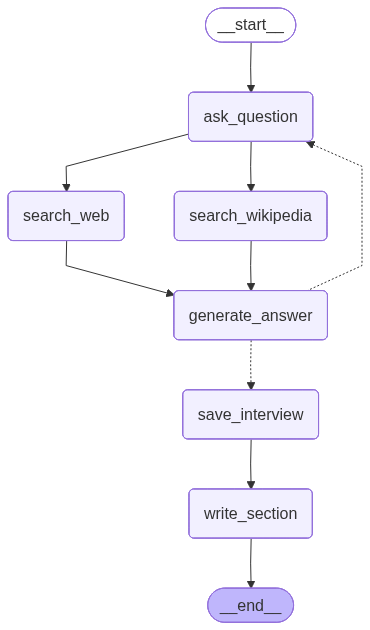

In [157]:
display(Image(interview_graph.get_graph().draw_mermaid_png()))

In [158]:
analyst

Analyst(name='Mahi', role='genai eng', affiliation='AI Research LAB', description='I am genai developer as well as mentor')

In [ ]:
analyst.persona

In [159]:
thread = {"configurable": {"thread_id": "1"}}

In [160]:
from IPython.display import Markdown

In [161]:
messages = [HumanMessage("So you said you were writing an article on Langchain?")]

In [162]:
interview = interview_graph.invoke({"analyst": analyst, "messages": messages, "max_num_turns": 2}, thread)


*******************************
search_query='Langchain AI development insights non-obvious surprising'
*******************************
search_query='advanced memory systems and intelligent callbacks in LangChain real-world applications'


In [163]:
Markdown(interview['sections'][0])

## Unlocking the Potential of LangChain: Insights for GenAI Developers and Mentors

### Summary

As a GenAI developer and mentor, understanding the evolving landscape of large language model (LLM) application development is crucial. The LangChain State of AI 2024 report and related insights provide a comprehensive overview of current trends and innovations in this field. The report highlights two major trends: the shift towards multi-step agentic workflows and the increasing adoption of open-source models for enhanced customization and scalability [1]. These trends reflect a maturation in AI development practices, emphasizing modularity, adaptability, and transparency in AI systems.

1. **Transition to Multi-Agent Workflows**: The move from retrieval-augmented generation (RAG) to multi-step, agentic applications marks a significant evolution in AI ecosystems. Developers are now creating modular agent architectures where agents perform specialized tasks such as data validation and decision analysis. This approach enhances workflow resilience and scalability, making it suitable for complex use cases [1].

2. **Agentic Reasoning and Orchestration**: Modern agent frameworks are incorporating advanced features like state management and self-correcting loops. Tools like LangGraph are central to designing cyclical workflows, allowing agents to dynamically adapt based on intermediate outputs. This significantly improves reasoning and problem-solving capabilities [1].

3. **Open-Source Model Adoption**: There is a clear trend towards using open-source LLMs like LLaMA and Falcon. These models offer customization, privacy, and deployment flexibility, allowing organizations to fine-tune them on domain-specific datasets. This facilitates rapid experimentation and deployment across various use cases without overhauling core architectures [1].

4. **Underutilized LangChain Features**: Many developers are not fully leveraging LangChain's capabilities, which can dramatically improve AI applications' performance and reliability. Features such as advanced memory systems and intelligent callbacks are often overlooked but are essential for creating production-ready AI applications [2].

5. **Challenges and Opportunities in Agent Analytics**: Unlike traditional software, AI agents are non-deterministic, meaning each LLM call can produce different outputs. This unpredictability presents challenges in analytics and requires innovative solutions like LangChain's Insights Agent, which clusters and analyzes trace records to provide actionable insights [3].

These insights underscore the importance of building adaptable, modular, and transparent AI systems. The convergence of agentic workflows, open-source adoption, and robust observability practices will continue to drive innovation and scalability in LLM applications. As a GenAI developer and mentor, embracing these trends and leveraging LangChain's advanced features can lead to significant advancements in AI application development.

### Sources
[1] https://www.linkedin.com/posts/ganeshjagadeesan_langchain-state-of-ai-2024-key-5-insights-activity-7279358609686208512-TYvI  
[2] https://medium.com/@muhibuddin12/7-langchain-features-youre-probably-ignoring-but-should-be-using-daily-67d18cab18d1  
[3] https://www.mexc.co/en-PH/news/520168  

third Workflow

In [166]:
from typing_extensions import TypedDict
from typing import List, Annotated
import operator
class ResearchGraphState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions
    sections: Annotated[list, operator.add] # Send() API key
    introduction: str # Introduction for the final report
    content: str # Content for the final report
    conclusion: str # Conclusion for the final report
    final_report: str # Final report
    
# class InterviewState(MessagesState):
#     max_num_turns: int # Number turns of conversation
#     context: Annotated[list, operator.add] # Source docs
#     analyst: Analyst # Analyst asking questions
#     interview: str # Interview transcript
#     sections: list # Final key we duplicate in outer state for Send() API



In [164]:
from langgraph.types import Send

In [167]:
def initiate_all_interviews(state:ResearchGraphState):
    """ This is the "map" step where we run each interview sub-graph using Send API """ 
    
    #check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback')
    if human_analyst_feedback:
        # Return to create_analysts
        return "create_analysts"
    
    # Otherwise kick off interviews in parallel via Send() API
    else:
        topic = state["topic"]
        return [Send("conduct_interview", {"analyst": analyst,
                                        "messages": [HumanMessage(
                                            content=f"So you said you were writing an article on {topic}?"
                                        )
                                                ]}) for analyst in state["analysts"]]

In [168]:
report_writer_instructions = """You are a technical writer creating a report on this overall topic: 

{topic}
    
You have a team of analysts. Each analyst has done two things: 

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task: 

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos. 
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:
 
1. Use markdown formatting. 
2. Include no pre-amble for the report.
3. Use no sub-heading. 
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from: 

{context}"""

In [169]:
def write_report(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    system_message = report_writer_instructions.format(topic=topic, context=formatted_str_sections)    
    report = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Write a report based upon these memos.")]) 
    return {"content": report.content}

In [170]:
intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting. 

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header. 

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

In [171]:
def write_introduction(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    intro = llm.invoke([instructions]+[HumanMessage(content=f"Write the report introduction")]) 
    return {"introduction": intro.content}

In [172]:
def write_conclusion(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    conclusion = llm.invoke([instructions]+[HumanMessage(content=f"Write the report conclusion")]) 
    return {"conclusion": conclusion.content}

In [173]:
def finalize_report(state: ResearchGraphState):
    """ The is the "reduce" step where we gather all the sections, combine them, and reflect on them to write the intro/conclusion """
    # Save full final report
    content = state["content"]
    if content.startswith("## Insights"):
        content = content.strip("## Insights")
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    final_report = state["introduction"] + "\n\n---\n\n" + content + "\n\n---\n\n" + state["conclusion"]
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
    return {"final_report": final_report}

In [174]:
# Add nodes and edges 
builder = StateGraph(ResearchGraphState)
builder.add_node("create_analysts", create_analyst)
builder.add_node("human_feedback", human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report",write_report)
builder.add_node("write_introduction",write_introduction)
builder.add_node("write_conclusion",write_conclusion)
builder.add_node("finalize_report",finalize_report)

# Logic
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")
builder.add_edge(["write_conclusion", "write_report", "write_introduction"], "finalize_report")
builder.add_edge("finalize_report", END)



In [175]:
memory = MemorySaver()

In [176]:
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)

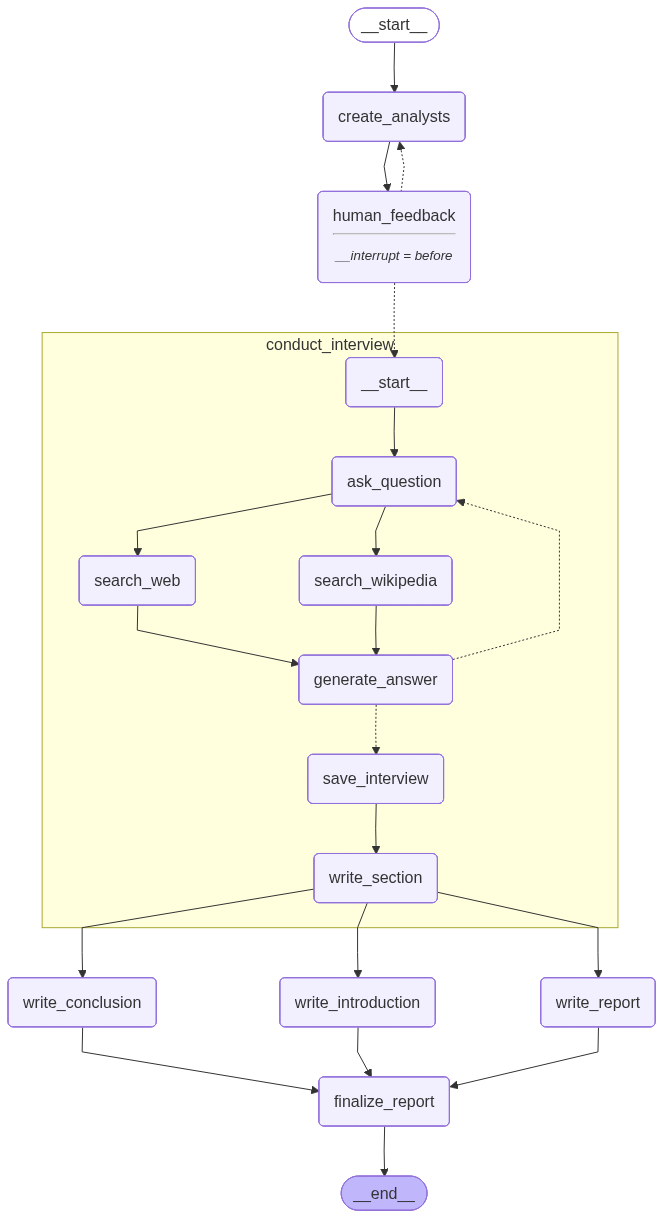

In [177]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [178]:
max_analysts = 3

In [179]:
topic = "How can generative help us to play the cricket?"

In [180]:
topic = "How can generative AI accelerate drug discovery?"

In [181]:
thread = {"configurable": {"thread_id": "1"}}

In [182]:
# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts}, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Dr. Emily Chen
Affiliation: Stanford University
Role: AI and Computational Biology Expert
Description: Dr. Chen focuses on the integration of generative AI models with biological data to enhance the drug discovery process. Her primary concern is ensuring that AI models are trained on diverse and comprehensive datasets to improve their predictive accuracy and reliability. She is motivated by the potential of AI to significantly reduce the time and cost associated with bringing new drugs to market.
--------------------------------------------------
Name: Dr. Raj Patel
Affiliation: Pfizer Inc.
Role: Pharmaceutical Industry Strategist
Description: Dr. Patel analyzes the strategic implications of adopting generative AI in pharmaceutical companies. He is concerned with how AI can streamline R&D processes, optimize resource allocation, and ultimately lead to more personalized medicine. His motive is to leverage AI to maintain competitive advantage and drive innovation in drug developmen

In [183]:
graph.update_state(thread, {"human_analyst_feedback":"along with the genetive ai in future tell me the future of indian team"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0f9317-a37c-612e-8002-c127e0391ca6'}}

In [184]:
# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts}, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Dr. Emily Chen
Affiliation: Stanford University
Role: AI and Computational Biology Expert
Description: Dr. Chen focuses on the integration of generative AI models with biological data to enhance the drug discovery process. Her primary concern is ensuring that AI models are trained on diverse and comprehensive datasets to improve their predictive accuracy and reliability. She is motivated by the potential of AI to significantly reduce the time and cost associated with bringing new drugs to market.
--------------------------------------------------
Name: Dr. Raj Patel
Affiliation: Pfizer Inc.
Role: Pharmaceutical Industry Strategist
Description: Dr. Patel analyzes the strategic implications of adopting generative AI in pharmaceutical companies. He is concerned with how AI can streamline R&D processes, optimize resource allocation, and ultimately lead to more personalized medicine. His motive is to leverage AI to maintain competitive advantage and drive innovation in drug developmen

In [185]:
graph.update_state(thread, {"human_analyst_feedback":""}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0f9318-c5ab-6f96-8006-4db9899d929c'}}

In [186]:
graph.get_state(thread).next

('conduct_interview', 'conduct_interview', 'conduct_interview')

In [188]:
# Continue
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)



RateLimitError: Error code: 429 - {'error': {'message': 'Request too large for gpt-4o in organization org-avNxol9aL3BqrZ8ay5hpL8YP on tokens per min (TPM): Limit 30000, Requested 35258. The input or output tokens must be reduced in order to run successfully. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}

In [189]:
from IPython.display import Markdown

In [190]:
final_state = graph.get_state(thread)

In [191]:
report = final_state.values.get('final_report')

In [192]:
Markdown(report)

<IPython.core.display.Markdown object>